# Backpropagation

En una Red Neuronal con $N$ capas queremos optimizar aplicando algún método del **Gradiente Decendente**:

$$
W^{(l)} := W^{(l)} - \lambda \frac{\partial \mathcal{L}}{\partial W^{(l)}}
$$

donde cada capa tiene:

$$
z^{(l)} = h^{(l-1)} W^{(l)} + b^{(l)}, \quad h^{(l)} = \phi(z^{(l)})
$$

y nuestra función de perdida:

$$
\mathcal{L} = \mathcal{L}(h^{[N]}, y)
$$

# La pérdida solo se conoce al final

Para actualizar una capa, necesitas su contribución al error

Por ejemplo, para actualizar $W^{[1]}$ necesitas:

$$
\frac{\partial \mathcal{L}}{\partial W^{[1]}}
$$

Usando la regla de la cadena:


$$
\frac{\partial \mathcal{L}}{\partial W^{[1]}} 
=
\frac{\partial \mathcal{L}}{\partial h^{[3]}}
\frac{\partial h^{[3]}}{\partial z^{[3]}}
\frac{\partial z^{[3]}}{\partial h^{[2]}}
\frac{\partial h^{[2]}}{\partial z^{[2]}}
\frac{\partial z^{[2]}}{\partial h^{[1]}}
\frac{\partial h^{[1]}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial W^{[1]}}
$$

Para actualizar la capa 1 necesitas todas las capas posteriores. ¿Que pasaría si empiezo desde la capa 1?

### Capa 1
$$
z^{[1]} = W^{[1]} x + b^{[1]}
$$

$$
h^{[1]} = \phi(z^{[1]})
$$

**Gradientes:**


$$
\frac{\partial \mathcal{L}}{\partial W^{[1]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial W^{[1]}}
$$


$$
\frac{\partial \mathcal{L}}{\partial b^{[1]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial b^{[1]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
= 
\frac{\partial \mathcal{L}}{\partial h^{[1]}}
\frac{\partial h^{[1]}}{\partial z^{[1]}}
$$

Si empiezas desde la capa 1:

- no tienes $\frac{\partial \mathcal{L}}{\partial h^{[1]}}$
- no tienes $\frac{\partial \mathcal{L}}{\partial z^{[1]}}$
- no sabes cuánto error proviene de cada neurona siguiente



## El error se distribuye hacia atrás

La red calcula:

$$
x \rightarrow h^{[1]} \rightarrow h^{[2]} \rightarrow h^{[3]} = \hat{y}
$$

y finalmente computa la pérdida:

$$
\mathcal{L}(\hat{y}, y)
$$

La pérdida $\mathcal{L}$ depende solo de la **salida final** $\hat{y}$.

Entonces:

- En la capa 1 no sabes el error
- En la capa 2 tampoco
- Solo en la capa de salida puedes calcular el error directamente.

Por lo tanto, el gradiente DEBE empezar en la capa de salida.


## Forward + Backpropagation (Ejemplo de Red Neuronal de 3 capas)

### Capa 3 (Salida)
$$
z^{[3]} = W^{[3]} h^{[2]} + b^{[3]}
$$

$$
\hat{y} = h^{[3]} = \phi(z^{[3]})
$$

**Pérdida:**
$$
\mathcal{L} = \mathcal{L}(\hat{y}, y)
$$

**Gradientes:**

$$
\frac{\partial \mathcal{L}}{\partial W^{[3]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[3]}}
\frac{\partial z^{[3]}}{\partial W^{[3]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial b^{[3]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[3]}}
\frac{\partial z^{[3]}}{\partial b^{[3]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial z^{[3]}}
= 
\frac{\partial \mathcal{L}}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z^{[3]}}
$$

---

### Capa 2
$$
z^{[2]} = W^{[2]} h^{[1]} + b^{[2]}
$$

$$
h^{[2]} = \phi(z^{[2]})
$$

**Gradientes:**


$$
\frac{\partial \mathcal{L}}{\partial W^{[2]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[2]}}
\frac{\partial z^{[2]}}{\partial W^{[2]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial b^{[2]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[2]}}
\frac{\partial z^{[2]}}{\partial b^{[2]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial z^{[2]}}
= 
\frac{\partial \mathcal{L}}{\partial h^{[2]}}
\frac{\partial h^{[2]}}{\partial z^{[2]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial h^{[2]}}
= 
\frac{\partial \mathcal{L}}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial h^{[2]}}
$$

---

### Capa 1
$$
z^{[1]} = W^{[1]} x + b^{[1]}
$$

$$
h^{[1]} = \phi(z^{[1]})
$$

**Gradientes:**

$$
\frac{\partial \mathcal{L}}{\partial W^{[1]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial W^{[1]}}
$$


$$
\frac{\partial \mathcal{L}}{\partial b^{[1]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial b^{[1]}}
$$


$$
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
= 
\frac{\partial \mathcal{L}}{\partial h^{[1]}}
\frac{\partial h^{[1]}}{\partial z^{[1]}}
$$


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
x = np.random.uniform(-1, 1, (100, 3)).astype(np.float32)
y = np.sum(x ** 2, axis = 1, keepdims = True).astype(np.float32)

### Inicialización de pesos.

In [4]:
W1 = tf.Variable(tf.random.normal([3, 10], stddev = 0.1))
b1 = tf.Variable(tf.zeros([10]))

W2 = tf.Variable(tf.random.normal([10, 8], stddev = 0.1))
b2 = tf.Variable(tf.zeros([8]))

W3 = tf.Variable(tf.random.normal([8, 1], stddev = 0.1))
b3 = tf.Variable(tf.zeros([1]))

In [5]:
W1

<tf.Variable 'Variable:0' shape=(3, 10) dtype=float32, numpy=
array([[-1.33005902e-01,  6.76648244e-02,  1.33264869e-01,
         7.19375461e-02, -1.35108875e-02, -7.24375173e-02,
        -9.20503661e-02, -2.39549093e-02, -2.33788732e-02,
        -1.48867503e-01],
       [-4.87133190e-02,  8.77890512e-02, -2.01820999e-01,
         2.40130350e-01,  5.59548335e-03, -3.91014367e-02,
        -7.87741095e-02,  2.56185140e-05, -6.19370416e-02,
        -5.27674146e-02],
       [-3.04438379e-02,  8.31817091e-02, -1.18781880e-01,
         1.33699536e-01,  1.94352232e-02,  1.20302990e-01,
         9.35971811e-02,  7.69205168e-02, -5.28086685e-02,
        -4.03863452e-02]], dtype=float32)>

In [6]:
b1

<tf.Variable 'Variable:0' shape=(10,) dtype=float32, numpy=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)>

In [7]:
tf.matmul(x, W1).shape

TensorShape([100, 10])

# ---- Forward pass ----

In [8]:
def forward(x):
    # Capa 1
    z1 = tf.matmul(x, W1) + b1
    h1 = tf.nn.relu(z1)
    
    # Capa 2
    z2 = tf.matmul(h1, W2) + b2
    h2 = tf.nn.relu(z2)
    
    # Capa de salida
    z3 = tf.matmul(h2, W3) + b3
    
    return z1, h1, z2, h2, z3

In [9]:
z1, h1, z2, h2, z3 = forward(x)

In [10]:
print(z1.shape , h1.shape)

(100, 10) (100, 10)


In [11]:
print(z2.shape , h2.shape)


(100, 8) (100, 8)


In [12]:
print(z3.shape)

(100, 1)


# Entrenamiento

In [13]:
lr = 0.1
epochs = 400

for epoch in range(epochs):
    # Forward
    z1, h1, z2, h2, y_pred = forward(x)
    loss = tf.reduce_mean((y - y_pred) ** 2)
    
    # ---- Backpropagation ----
    # dL/dy_pred
    dL_dy = 2 * (y_pred - y) / x.shape[0]  # (100,1)

    # --- Gradientes para capa 3 (salida) ---
    dL_dW3 = tf.matmul(tf.transpose(h2), dL_dy)  # (8,100)*(100,1)=(8,1)
    dL_db3 = tf.reduce_sum(dL_dy, axis=0)        # (1,)

    # --- Gradientes para capa 2 ---
    dL_dh2 = tf.matmul(dL_dy, tf.transpose(W3))  # (100,1)*(1,8)=(100,8)
    dh2_dz2 = tf.cast(z2 > 0, tf.float32)        # derivada ReLU
    dL_dz2 = dL_dh2 * dh2_dz2                    # (100,8)

    dL_dW2 = tf.matmul(tf.transpose(h1), dL_dz2) # (10,100)*(100,8)=(10,8)
    dL_db2 = tf.reduce_sum(dL_dz2, axis=0)       # (8,)

    # --- Gradientes para capa 1 ---
    dL_dh1 = tf.matmul(dL_dz2, tf.transpose(W2)) # (100,8)*(8,10)=(100,10)
    dh1_dz1 = tf.cast(z1 > 0, tf.float32)
    dL_dz1 = dL_dh1 * dh1_dz1                    # (100,10)

    dL_dW1 = tf.matmul(tf.transpose(x), dL_dz1)  # (3,100)*(100,10)=(3,10)
    dL_db1 = tf.reduce_sum(dL_dz1, axis=0)       # (10,)

    # ---- Actualización de pesos ----
    W1.assign_sub(lr * dL_dW1)
    b1.assign_sub(lr * dL_db1)
    W2.assign_sub(lr * dL_dW2)
    b2.assign_sub(lr * dL_db2)
    W3.assign_sub(lr * dL_dW3)
    b3.assign_sub(lr * dL_db3)

    # ---- Monitoreo ----
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.numpy():.6f}")

Epoch   0 | Loss: 1.294382
Epoch  50 | Loss: 0.214391
Epoch 100 | Loss: 0.213453
Epoch 150 | Loss: 0.211804
Epoch 200 | Loss: 0.208723
Epoch 250 | Loss: 0.202903
Epoch 300 | Loss: 0.193045
Epoch 350 | Loss: 0.178877


# Evaluación

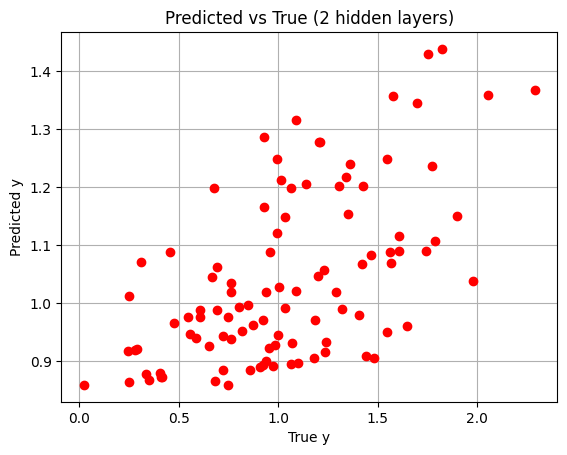

In [15]:
_, _, _, _, y_pred = forward(x)
plt.plot(y, y_pred, 'ro')
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Predicted vs True (2 hidden layers)")
plt.grid()
plt.show()